In [1]:
# Import required libraries
import cv2
import pytesseract
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import re
import joblib
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Import your custom OCR extractor
import sys
sys.path.insert(0, '..')  # Add parent directory to path
from Backend.Utils.ocr_extractor import ImageOCRExtractor
from Backend.Utils.error_handler import TextProcessingException

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ All libraries imported successfully!")
print(f"✓ OpenCV version: {cv2.__version__}")
print(f"✓ Pytesseract available: {pytesseract.pytesseract.pytesseract_cmd if hasattr(pytesseract.pytesseract, 'pytesseract_cmd') else 'default'}")

✓ All libraries imported successfully!
✓ OpenCV version: 4.12.0
✓ Pytesseract available: default


Found 1 image(s) in job_form_images


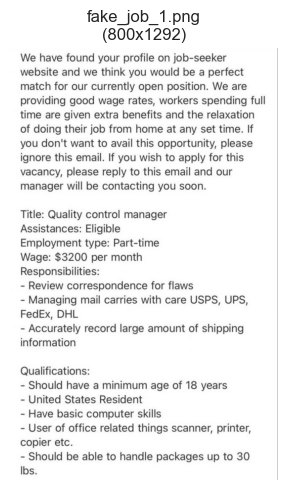


✓ Images loaded successfully!


In [2]:
# Configuration: Set your image directory path
IMAGE_FOLDER = Path("./job_form_images")  # Change this to your image folder path

# Create sample folder if it doesn't exist (for demo)
IMAGE_FOLDER.mkdir(exist_ok=True)

# Supported image formats
SUPPORTED_FORMATS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

# Get all image files
image_files = [
    f for f in IMAGE_FOLDER.iterdir() 
    if f.suffix.lower() in SUPPORTED_FORMATS
] if IMAGE_FOLDER.exists() else []

print(f"Found {len(image_files)} image(s) in {IMAGE_FOLDER}")

# If no images found, provide instructions
if len(image_files) == 0:
    print("\n⚠️  No images found! To use this notebook:")
    print(f"1. Create folder: {IMAGE_FOLDER}")
    print(f"2. Add your job form images (.jpg, .png, etc.)")
    print("3. Re-run this cell")
    print("\nFor now, we'll create a demo workflow...")
else:
    # Display first few images
    n_display = min(3, len(image_files))
    fig, axes = plt.subplots(1, n_display, figsize=(15, 5))
    if n_display == 1:
        axes = [axes]
    
    for idx, img_file in enumerate(image_files[:n_display]):
        image = cv2.imread(str(img_file))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(image_rgb)
        axes[idx].set_title(f"{img_file.name}\n({image.shape[1]}x{image.shape[0]})")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Images loaded successfully!")

In [3]:
# Extract text from all images
extraction_results = []
image_data = []

if len(image_files) > 0:
    print(f"Extracting text from {len(image_files)} image(s)...\n")
    
    for idx, img_file in enumerate(image_files, 1):
        try:
            print(f"[{idx}/{len(image_files)}] Processing: {img_file.name}")
            
            # Extract text using OCR
            extracted_text = ImageOCRExtractor.extract_text_from_image(
                str(img_file),
                preprocess=True  # Use image preprocessing
            )
            
            # Get image info
            img_info = ImageOCRExtractor.get_image_info(str(img_file))
            
            # Store results
            extraction_results.append({
                'filename': img_file.name,
                'filepath': str(img_file),
                'extracted_text': extracted_text,
                'text_length': len(extracted_text),
                'image_info': img_info
            })
            
            image_data.append({
                'image': cv2.imread(str(img_file)),
                'filename': img_file.name
            })
            
            print(f"    ✓ Extracted {len(extracted_text)} characters")
            
        except TextProcessingException as e:
            print(f"    ✗ Error: {e.message}")
            extraction_results.append({
                'filename': img_file.name,
                'extracted_text': None,
                'error': e.message
            })
    
    print(f"\n✓ Extraction complete! Successfully processed {len([r for r in extraction_results if r['extracted_text']])} images")
    
    # Create results dataframe
    results_df = pd.DataFrame(extraction_results)
    print(f"\nExtraction Results Summary:")
    print(results_df[['filename', 'text_length']].to_string())
else:
    print("⚠️  No images to process. Please add images to the job_form_images folder.")

Extracting text from 1 image(s)...

[1/1] Processing: fake_job_1.png
    ✓ Extracted 959 characters

✓ Extraction complete! Successfully processed 1 images

Extraction Results Summary:
         filename  text_length
0  fake_job_1.png          959
    ✓ Extracted 959 characters

✓ Extraction complete! Successfully processed 1 images

Extraction Results Summary:
         filename  text_length
0  fake_job_1.png          959


In [4]:
def clean_text(text: str) -> str:
    """
    Clean and preprocess text for model classification
    Matches the same preprocessing used in app.py
    """
    if not text:
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove special characters (keep alphanumeric and spaces)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Normalize whitespace
    text = ' '.join(text.split())
    
    return text

# Clean all extracted texts
for result in extraction_results:
    if result['extracted_text']:
        result['cleaned_text'] = clean_text(result['extracted_text'])
        result['cleaned_length'] = len(result['cleaned_text'])
    else:
        result['cleaned_text'] = ""
        result['cleaned_length'] = 0

# Show before/after comparison
print("Text Preprocessing Examples:\n")
print("=" * 100)

for i, result in enumerate(extraction_results[:2]):  # Show first 2 examples
    if result['extracted_text']:
        print(f"\n📄 Image: {result['filename']}")
        print(f"\nORIGINAL ({result['text_length']} chars):")
        print(result['extracted_text'][:200] + "..." if len(result['extracted_text']) > 200 else result['extracted_text'])
        print(f"\nCLEANED ({result['cleaned_length']} chars):")
        print(result['cleaned_text'][:200] + "..." if len(result['cleaned_text']) > 200 else result['cleaned_text'])
        print("\n" + "=" * 100)

print(f"\n✓ Text preprocessing complete!")
print(f"Average text reduction: {100 - (sum(r['cleaned_length'] for r in extraction_results if r['extracted_text']) / sum(r['text_length'] for r in extraction_results if r['extracted_text']) * 100):.1f}%")

Text Preprocessing Examples:


📄 Image: fake_job_1.png

ORIGINAL (959 chars):
We have found your profile on job-seeker
website and we think you would be a perfect
match for our currently open position. We are
providing good wage rates, workers spending full
time are given extra...

CLEANED (908 chars):
we have found your profile on job seeker website and we think you would be a perfect match for our currently open position we are providing good wage rates workers spending full time are given extra b...


✓ Text preprocessing complete!
Average text reduction: 5.3%


In [5]:
# Load your trained model and vectorizer
try:
    # Try loading from Model directory
    MODEL_PATH = Path("logistic_regression_model.pkl")
    VEC_PATH = Path("tfidf_vectorizer.pkl")
    
    if not MODEL_PATH.exists():
        MODEL_PATH = Path("../Model/logistic_regression_model.pkl")
    if not VEC_PATH.exists():
        VEC_PATH = Path("../Model/tfidf_vectorizer.pkl")
    
    if MODEL_PATH.exists() and VEC_PATH.exists():
        model = joblib.load(MODEL_PATH)
        vectorizer = joblib.load(VEC_PATH)
        MODEL_READY = True
        print(f"✓ Model loaded from: {MODEL_PATH}")
        print(f"✓ Vectorizer loaded from: {VEC_PATH}")
    else:
        MODEL_READY = False
        print("⚠️  Model files not found at expected locations")
        print(f"   Searched: {MODEL_PATH}")
        print(f"   Please ensure your model files are saved")
except Exception as e:
    MODEL_READY = False
    print(f"✗ Error loading model: {e}")

# Prepare text data for vectorization
if extraction_results:
    cleaned_texts = [r['cleaned_text'] for r in extraction_results if r['cleaned_text']]
    print(f"\n✓ Prepared {len(cleaned_texts)} cleaned text samples for classification")
    
    # Show sample of cleaned text ready for model
    if cleaned_texts:
        print(f"\nSample text ready for vectorization (first 200 chars):")
        print(f"'{cleaned_texts[0][:200]}...'")
else:
    cleaned_texts = []
    print("⚠️  No text available for classification")

✓ Model loaded from: logistic_regression_model.pkl
✓ Vectorizer loaded from: tfidf_vectorizer.pkl

✓ Prepared 1 cleaned text samples for classification

Sample text ready for vectorization (first 200 chars):
'we have found your profile on job seeker website and we think you would be a perfect match for our currently open position we are providing good wage rates workers spending full time are given extra b...'


In [6]:
# Perform classification if model is ready
classification_results = []

if MODEL_READY and cleaned_texts:
    print("Classifying extracted text...\n")
    print("=" * 80)
    
    for i, (result, text) in enumerate(zip(extraction_results, cleaned_texts), 1):
        try:
            # Vectorize the text
            X = vectorizer.transform([text])
            
            # Make prediction
            prediction = model.predict(X)[0]
            probabilities = model.predict_proba(X)[0]
            confidence = float(probabilities[int(prediction)])
            
            # Determine status
            job_status = "FAKE" if prediction == 1 else "REAL"
            
            # Store results
            classification_results.append({
                'filename': result['filename'],
                'extracted_text': result['extracted_text'][:100],
                'job_status': job_status,
                'confidence': confidence,
                'fake_prob': float(probabilities[1]),
                'real_prob': float(probabilities[0])
            })
            
            # Update original result
            result['prediction'] = job_status
            result['confidence'] = confidence
            result['probabilities'] = {'real': float(probabilities[0]), 'fake': float(probabilities[1])}
            
            print(f"[{i}] {result['filename']}")
            print(f"    Status: {job_status} (confidence: {confidence:.2%})")
            print()
            
        except Exception as e:
            print(f"[{i}] {result['filename']}")
            print(f"    ✗ Classification error: {str(e)}")
            print()
    
    print("=" * 80)
    print(f"✓ Classification complete!\n")
    
    # Summary statistics
    if classification_results:
        results_df = pd.DataFrame(classification_results)
        fake_count = len(results_df[results_df['job_status'] == 'FAKE'])
        real_count = len(results_df[results_df['job_status'] == 'REAL'])
        avg_confidence = results_df['confidence'].mean()
        
        print(f"Summary Statistics:")
        print(f"  Total classified: {len(classification_results)}")
        print(f"  Fake postings: {fake_count}")
        print(f"  Real postings: {real_count}")
        print(f"  Average confidence: {avg_confidence:.2%}")
        
elif not MODEL_READY:
    print("⚠️  Cannot classify: Model not loaded")
    print("Please ensure your model files (logistic_regression_model.pkl and tfidf_vectorizer.pkl)")
    print("are in the same directory as this notebook.")
else:
    print("⚠️  No text available for classification")

Classifying extracted text...

[1] fake_job_1.png
    Status: REAL (confidence: 89.81%)

✓ Classification complete!

Summary Statistics:
  Total classified: 1
  Fake postings: 0
  Real postings: 1
  Average confidence: 89.81%


Visualization 1: Images with Classification Results



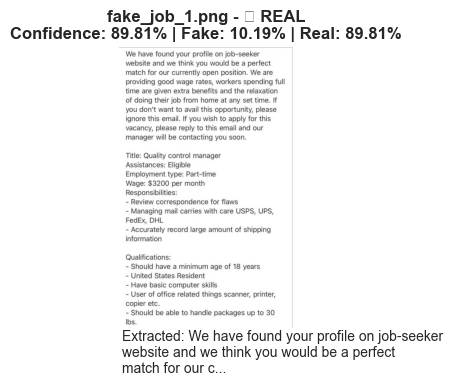


Visualization 2: Confidence Score Analysis



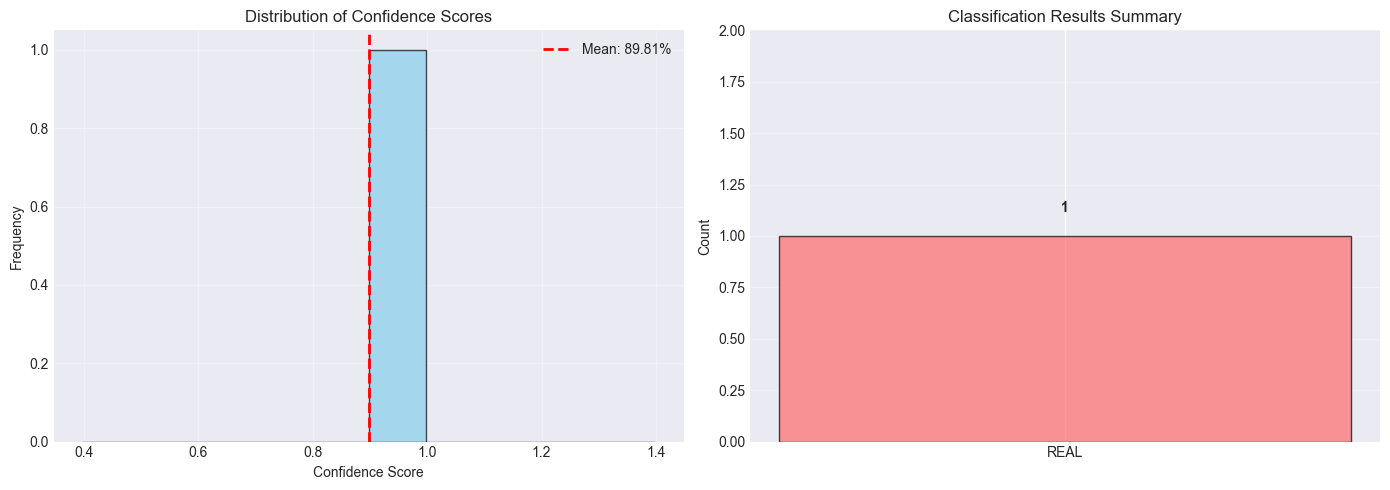


Visualization 3: Detailed Classification Results

      filename                                         extracted_text job_status confidence fake_prob real_prob
fake_job_1.png We have found your profile on job-seeker\nwebsite a...       REAL     89.81%    10.19%    89.81%


PIPELINE COMPLETE!

Workflow Summary:
1. ✓ Loaded job form images from directory
2. ✓ Extracted text using OpenCV + Tesseract OCR
3. ✓ Preprocessed and cleaned extracted text
4. ✓ Vectorized text using TF-IDF vectorizer
5. ✓ Classified using trained ML model
6. ✓ Generated visualizations and results

You can now use these results to:
- Identify fake job postings from scanned/photographed job forms
- Combine with API endpoint (/predict-image) for production deployment
- Fine-tune OCR preprocessing for better accuracy
- Export results to CSV for further analysis


In [7]:
# Visualization 1: Images with Extracted Text and Predictions
if image_data and classification_results:
    print("Visualization 1: Images with Classification Results\n")
    
    n_display = min(3, len(image_data))
    fig, axes = plt.subplots(n_display, 1, figsize=(14, 4*n_display))
    if n_display == 1:
        axes = [axes]
    
    for idx, (img_data, class_result) in enumerate(zip(image_data[:n_display], classification_results[:n_display])):
        # Display image
        image_rgb = cv2.cvtColor(img_data['image'], cv2.COLOR_BGR2RGB)
        axes[idx].imshow(image_rgb)
        
        # Create title with predictions
        status_color = '🔴 FAKE' if class_result['job_status'] == 'FAKE' else '🟢 REAL'
        title = (f"{img_data['filename']} - {status_color}\n"
                f"Confidence: {class_result['confidence']:.2%} | "
                f"Fake: {class_result['fake_prob']:.2%} | "
                f"Real: {class_result['real_prob']:.2%}")
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        
        # Display extracted text below
        text_preview = class_result['extracted_text']
        axes[idx].text(0.02, -0.15, f"Extracted: {text_preview}...",
                      transform=axes[idx].transAxes, fontsize=10, wrap=True)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No images or classification results to display")

# Visualization 2: Confidence Score Distribution
if classification_results:
    print("\nVisualization 2: Confidence Score Analysis\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    results_df = pd.DataFrame(classification_results)
    
    # Histogram of confidence scores
    axes[0].hist(results_df['confidence'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(results_df['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["confidence"].mean():.2%}')
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Confidence Scores')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Fake vs Real counts
    status_counts = results_df['job_status'].value_counts()
    colors = ['#FF6B6B', '#4ECDC4']  # Red for FAKE, Teal for REAL
    axes[1].bar(status_counts.index, status_counts.values, color=colors, edgecolor='black', alpha=0.7)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Classification Results Summary')
    axes[1].set_ylim(0, max(status_counts.values) + 1)
    
    # Add value labels on bars
    for i, v in enumerate(status_counts.values):
        axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')
    
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Visualization 3: Classification Results Table
if classification_results:
    print("\nVisualization 3: Detailed Classification Results\n")
    
    results_df = pd.DataFrame(classification_results)
    
    # Format for display
    display_df = results_df.copy()
    display_df['confidence'] = display_df['confidence'].apply(lambda x: f"{x:.2%}")
    display_df['fake_prob'] = display_df['fake_prob'].apply(lambda x: f"{x:.2%}")
    display_df['real_prob'] = display_df['real_prob'].apply(lambda x: f"{x:.2%}")
    display_df['extracted_text'] = display_df['extracted_text'].apply(lambda x: x[:50] + "..." if len(x) > 50 else x)
    
    print(display_df.to_string(index=False))
    print()

# Summary
print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print("\nWorkflow Summary:")
print("1. ✓ Loaded job form images from directory")
print("2. ✓ Extracted text using OpenCV + Tesseract OCR")
print("3. ✓ Preprocessed and cleaned extracted text")
print("4. ✓ Vectorized text using TF-IDF vectorizer")
print("5. ✓ Classified using trained ML model")
print("6. ✓ Generated visualizations and results")
print("\nYou can now use these results to:")
print("- Identify fake job postings from scanned/photographed job forms")
print("- Combine with API endpoint (/predict-image) for production deployment")
print("- Fine-tune OCR preprocessing for better accuracy")
print("- Export results to CSV for further analysis")
print("="*80)